# Slide-seq_MOB

In [1]:
import warnings
warnings.filterwarnings("ignore")
import MENDER
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import *
import time

In [2]:
## load the data using pysodb, please install pysodb in advance [https://pysodb.readthedocs.io/en/latest/]
import pysodb
sodb = pysodb.SODB()
adata_raw = sodb.load_experiment('stickels2020highly','stickels2021highly_SlideSeqV2_Mouse_Olfactory_bulb_Puck_200127_15')




download experiment[stickels2021highly_SlideSeqV2_Mouse_Olfactory_bulb_Puck_200127_15] in dataset[stickels2020highly]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 114M/114M [00:08<00:00, 14.0MB/s]


load experiment[stickels2021highly_SlideSeqV2_Mouse_Olfactory_bulb_Puck_200127_15] in dataset[stickels2020highly]


In [12]:
adata_raw.shape

(20139, 15149)

In [3]:
# Downloaded from https://drive.google.com/drive/folders/10lhz5VY7YfvHrtV40MwaqLmWz56U9eBP?usp=sharing
used_barcode = pd.read_csv('data/used_barcodes.txt', sep='\t', header=None)
used_barcode = used_barcode[0]

In [4]:
adata_raw = adata_raw[used_barcode,]

In [5]:
sc.pp.filter_cells(adata_raw, min_counts=10)
sc.pp.filter_genes(adata_raw, min_cells=10)

In [6]:
adata_raw.layers["counts"] = adata_raw.X.copy()
sc.pp.highly_variable_genes(adata_raw, flavor="seurat_v3", n_top_genes=4000)
sc.pp.normalize_total(adata_raw, inplace=True)
sc.pp.log1p(adata_raw)
sc.pp.pca(adata_raw)
sc.pp.neighbors(adata_raw)
sc.tl.umap(adata_raw)
sc.tl.leiden(adata_raw,resolution=2)

In [7]:
adata = adata_raw.copy()

In [8]:
# input parameters of MENDER
scale = 4

# main body of MENDER
msm = MENDER.MENDER_single(
    adata,
    # determine which cell state to use
    # we use the cell state got by Leiden
    ct_obs='leiden'
)


estimated radius: 15.93267083699364


In [9]:


# set the MENDER parameters


msm.set_MENDER_para(
    # default of n_scales is 6
    n_scales=scale, 
    
    # for single cell data, nn_mode is set to 'radius' 
    nn_mode='radius',
    
    # default of n_scales is 15 um (see the manuscript for why).
    # MENDER also provide a function 'estimate_radius' for estimating the radius
    nn_para=15, 

)
# construct the context representation
msm.run_representation(
    
    # the number of processings
)

# set the spatial clustering parameter
# positive values for the expected number of domains
# negative values for the clustering resolution
msm.run_clustering_normal(-0.5)



scale 0, median #cells per radius (r=15): 1.0
scale 1, median #cells per radius (r=15): 3.0
scale 2, median #cells per radius (r=15): 5.0
scale 3, median #cells per radius (r=15): 7.0


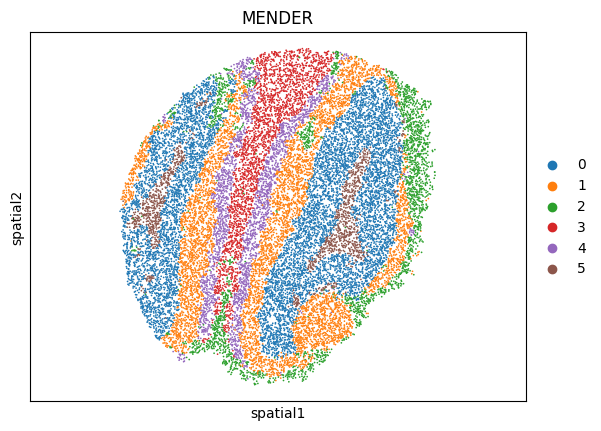

In [10]:
msm.output_cluster('MENDER')

In [11]:
msm.adata_MENDER.write_h5ad('dump/Slide-seq_MOB.h5ad')